In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported!")

Libraries imported!


In [4]:
import os
for dirname, _, filenames in os.walk('//kaggle/input/datasets/harshtiwari810972/cholera-and-water-quality-ipnb'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

//kaggle/input/datasets/harshtiwari810972/cholera-and-water-quality-ipnb/data.csv


In [5]:
df = pd.read_csv('/kaggle/input/datasets/harshtiwari810972/cholera-and-water-quality-ipnb/data.csv')

print("Dataset Loaded!")
print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head()

Dataset Loaded!
Shape: (2492, 6)
Columns: ['Country', 'Year', 'Number of reported cases of cholera', 'Number of reported deaths from cholera', 'Cholera case fatality rate', 'WHO Region']


,Country,Year,Number of reported cases of cholera,Number of reported deaths from cholera,Cholera case fatality rate,WHO Region
0,Afghanistan,2016,677,5,0.7,Eastern Mediterranean
1,Afghanistan,2015,58064,8,0.01,Eastern Mediterranean
2,Afghanistan,2014,45481,4,0.0,Eastern Mediterranean
3,Afghanistan,2013,3957,14,0.35,Eastern Mediterranean
4,Afghanistan,2012,12,0,0.1,Eastern Mediterranean


In [6]:
# Dataset ki basic info
print("Dataset Info:")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

print("\n Statistical Summary:")
print(df.describe())

print("\n Missing Values:")
print(df.isnull().sum())

print("\n Year Range:")
print(f"{df['Year'].min()} – {df['Year'].max()}")

print("\n Total Countries:")
print(df['Country'].nunique())

print("\n WHO Regions:")
print(df['WHO Region'].unique())

Dataset Info:
Rows: 2492
Columns: 6

 Statistical Summary:
              Year
count  2492.000000
mean   1992.343098
std      14.834151
min    1949.000000
25%    1981.000000
50%    1994.000000
75%    2004.000000
max    2016.000000

 Missing Values:
Country                                     0
Year                                        0
Number of reported cases of cholera        22
Number of reported deaths from cholera    117
Cholera case fatality rate                127
WHO Region                                  0
dtype: int64

 Year Range:
1949 – 2016

 Total Countries:
162

 WHO Regions:
['Eastern Mediterranean' 'Europe' 'Africa' 'Americas' 'Western Pacific'
 'South-East Asia']


In [7]:
# Column names short karte hain - easy kaam karne ke liye
df.columns = ['Country', 'Year', 'Cases', 'Deaths', 'Fatality_Rate', 'WHO_Region']

# String to number convert karo
df['Cases'] = pd.to_numeric(df['Cases'], errors='coerce')
df['Deaths'] = pd.to_numeric(df['Deaths'], errors='coerce')
df['Fatality_Rate'] = pd.to_numeric(df['Fatality_Rate'], errors='coerce')

# Missing values fill karo median se
df['Cases'].fillna(df['Cases'].median(), inplace=True)
df['Deaths'].fillna(df['Deaths'].median(), inplace=True)
df['Fatality_Rate'].fillna(df['Fatality_Rate'].median(), inplace=True)

print(" Data Cleaned!")
print(f"\nMissing values after cleaning:")
print(df.isnull().sum())
print("\nData Types:")
print(df.dtypes)
df.head()

 Data Cleaned!

Missing values after cleaning:
Country          0
Year             0
Cases            0
Deaths           0
Fatality_Rate    0
WHO_Region       0
dtype: int64

Data Types:
Country           object
Year               int64
Cases            float64
Deaths           float64
Fatality_Rate    float64
WHO_Region        object
dtype: object


,Country,Year,Cases,Deaths,Fatality_Rate,WHO_Region
0,Afghanistan,2016,677.0,5.0,0.70,Eastern Mediterranean
1,Afghanistan,2015,58064.0,8.0,0.01,Eastern Mediterranean
2,Afghanistan,2014,45481.0,4.0,0.00,Eastern Mediterranean
3,Afghanistan,2013,3957.0,14.0,0.35,Eastern Mediterranean
4,Afghanistan,2012,12.0,0.0,0.10,Eastern Mediterranean


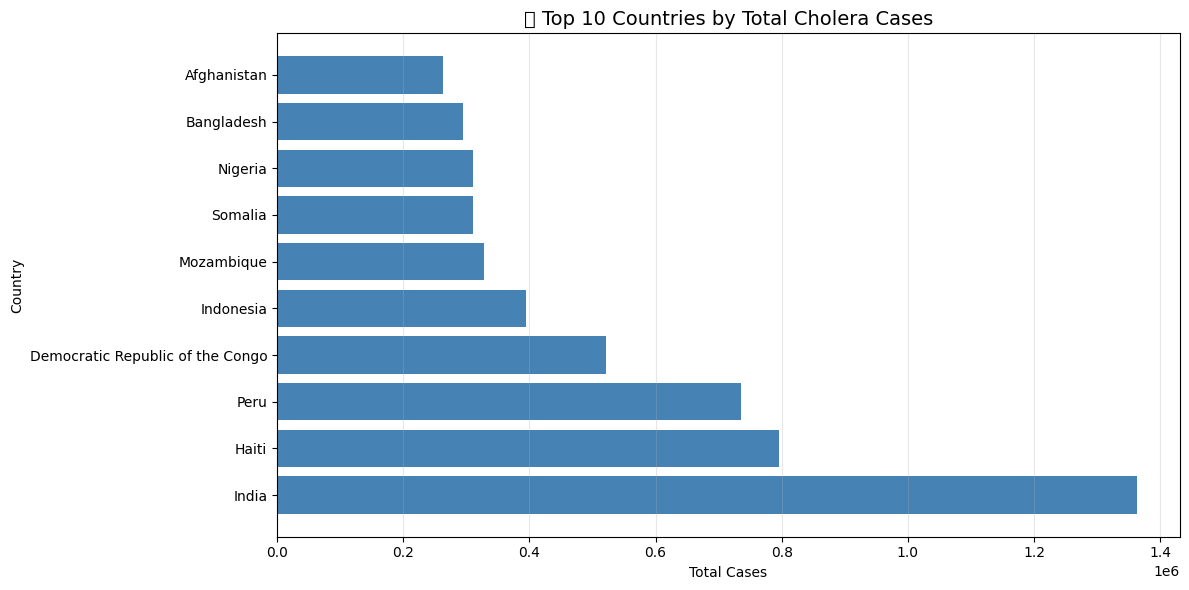

✅ Plot 1 Done!


In [8]:
# Plot 1: Top 10 Countries by Total Cholera Cases
plt.figure(figsize=(12, 6))

top_countries = df.groupby('Country')['Cases'].sum().nlargest(10)

plt.barh(top_countries.index, top_countries.values, color='steelblue')
plt.title('🦠 Top 10 Countries by Total Cholera Cases', fontsize=14)
plt.xlabel('Total Cases')
plt.ylabel('Country')
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print("✅ Plot 1 Done!")

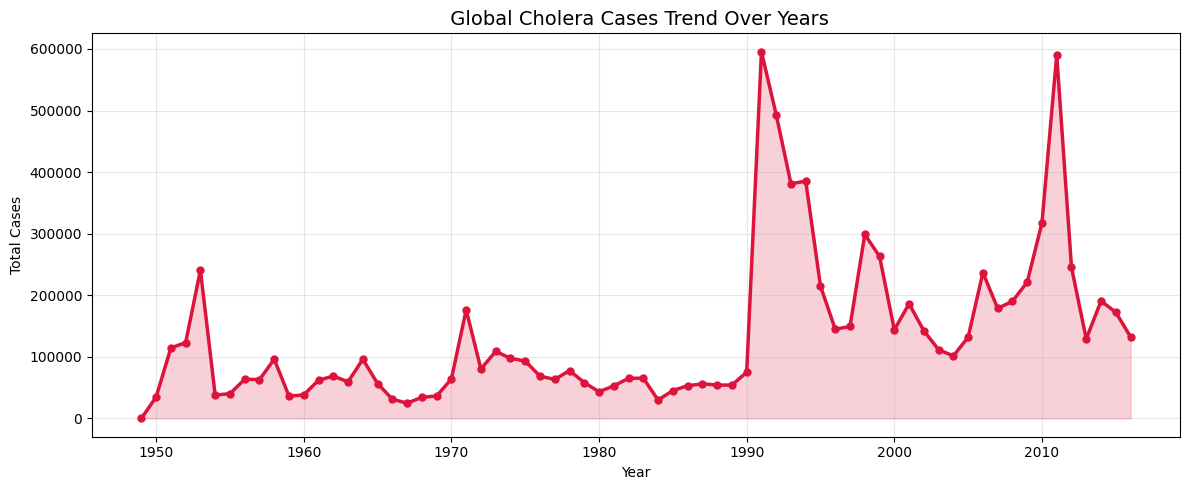

 Plot 2 Done!


In [9]:
# Plot 2: Yearly Cholera Cases Trend (Global)
plt.figure(figsize=(12, 5))

yearly = df.groupby('Year')['Cases'].sum()

plt.plot(yearly.index, yearly.values, color='crimson', lw=2.5, marker='o', ms=5)
plt.fill_between(yearly.index, yearly.values, alpha=0.2, color='crimson')
plt.title(' Global Cholera Cases Trend Over Years', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Total Cases')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(" Plot 2 Done!")

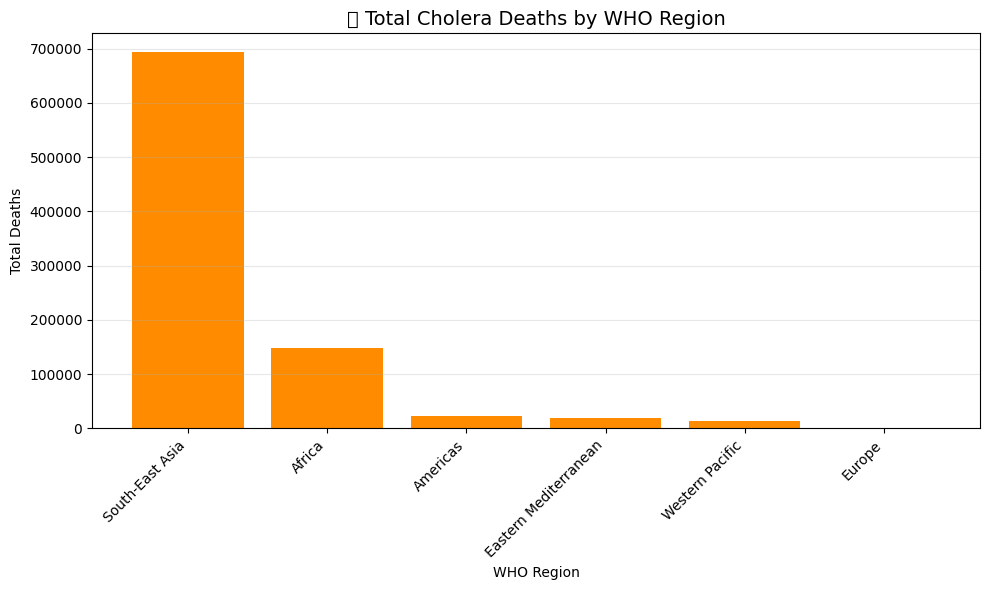

 Plot 3 Done!


In [10]:
# Plot 3: WHO Region wise Deaths
plt.figure(figsize=(10, 6))

region_deaths = df.groupby('WHO_Region')['Deaths'].sum().sort_values(ascending=False)

plt.bar(region_deaths.index, region_deaths.values, color='darkorange')
plt.title('💀 Total Cholera Deaths by WHO Region', fontsize=14)
plt.xlabel('WHO Region')
plt.ylabel('Total Deaths')
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print(" Plot 3 Done!")

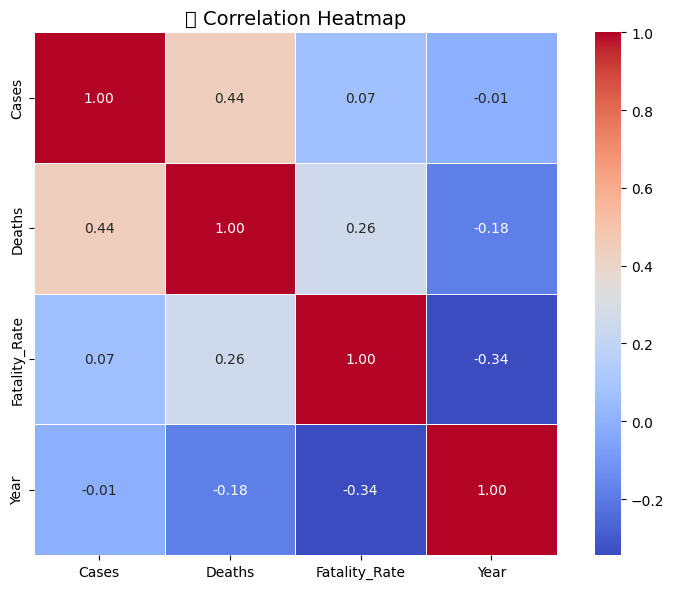

 Plot 4 Done!


In [11]:
# Plot 4: Correlation Heatmap
plt.figure(figsize=(8, 6))

corr = df[['Cases', 'Deaths', 'Fatality_Rate', 'Year']].corr()

sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True)
plt.title('🔗 Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

print(" Plot 4 Done!")

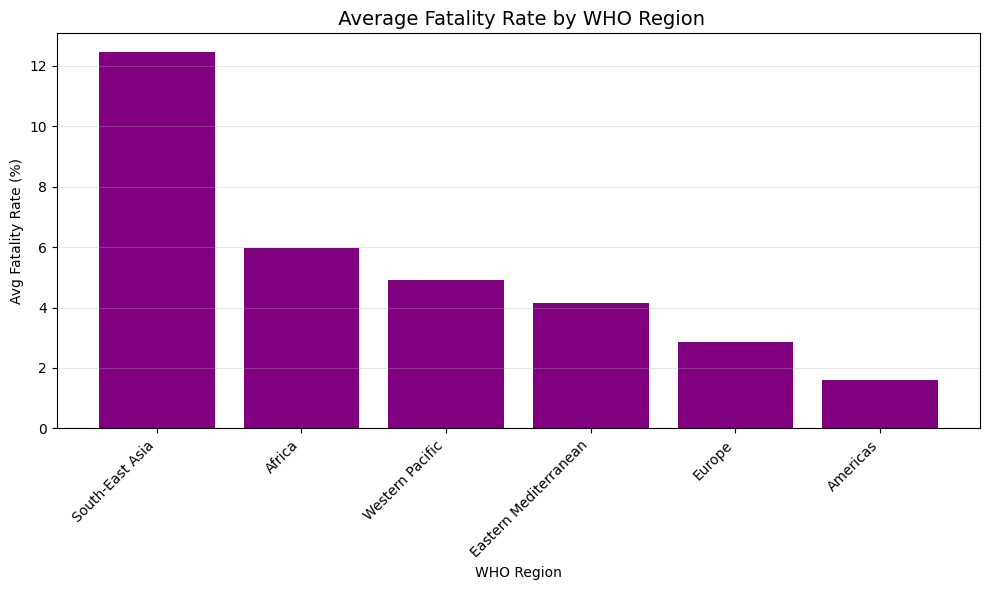

 Plot 5 Done!


In [12]:
# Plot 5: Average Fatality Rate by WHO Region
plt.figure(figsize=(10, 6))

region_fatality = df.groupby('WHO_Region')['Fatality_Rate'].mean().sort_values(ascending=False)

plt.bar(region_fatality.index, region_fatality.values, color='purple')
plt.title(' Average Fatality Rate by WHO Region', fontsize=14)
plt.xlabel('WHO Region')
plt.ylabel('Avg Fatality Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print(" Plot 5 Done!")

In [13]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

# Features aur Target define karo
X = df[['Cases', 'Fatality_Rate', 'Year']]
y = df['Deaths']

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model train karo
model = LinearRegression()
model.fit(X_train, y_train)

# Predict karo
y_pred = model.predict(X_test)

# Results
r2   = r2_score(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5

print(" ML Model Results:")
print(f"   R² Score : {r2:.4f}")
print(f"   RMSE     : {rmse:.4f}")
print("\n Model Trained!")

 ML Model Results:
   R² Score : -0.7880
   RMSE     : 2167.4294

 Model Trained!


In [15]:
from sklearn.preprocessing import StandardScaler

# Scaling karo
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# Dobara train karo
model2 = LinearRegression()
model2.fit(X_train_sc, y_train)

# Predict
y_pred2 = model2.predict(X_test_sc)

# Results
r2_2   = r2_score(y_test, y_pred2)
rmse_2 = mean_squared_error(y_test, y_pred2) ** 0.5

print(" Improved Model Results:")
print(f"   R² Score : {r2_2:.4f}")
print(f"   RMSE     : {rmse_2:.4f}")
print("\n Model Improved!")

 Improved Model Results:
   R² Score : -0.7880
   RMSE     : 2167.4294

 Model Improved!


In [16]:
from sklearn.ensemble import RandomForestRegressor

# Outliers remove karo
Q1 = df['Cases'].quantile(0.25)
Q3 = df['Cases'].quantile(0.75)
IQR = Q3 - Q1
df_clean = df[(df['Cases'] >= Q1 - 1.5*IQR) & (df['Cases'] <= Q3 + 1.5*IQR)]

print(f"Original rows: {len(df)}")
print(f"After removing outliers: {len(df_clean)}")

# Features aur Target
X2 = df_clean[['Cases', 'Fatality_Rate', 'Year']]
y2 = df_clean['Deaths']

X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, y2, test_size=0.2, random_state=42)

# Random Forest use karo - better model hai
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train2, y_train2)
y_pred_rf = rf_model.predict(X_test2)

r2_rf   = r2_score(y_test2, y_pred_rf)
rmse_rf = mean_squared_error(y_test2, y_pred_rf) ** 0.5

print(f"\n Random Forest Results:")
print(f"   R² Score : {r2_rf:.4f}")
print(f"   RMSE     : {rmse_rf:.4f}")
print("\n Done!")

Original rows: 2492
After removing outliers: 2127

 Random Forest Results:
   R² Score : 0.8786
   RMSE     : 46.9743

 Done!


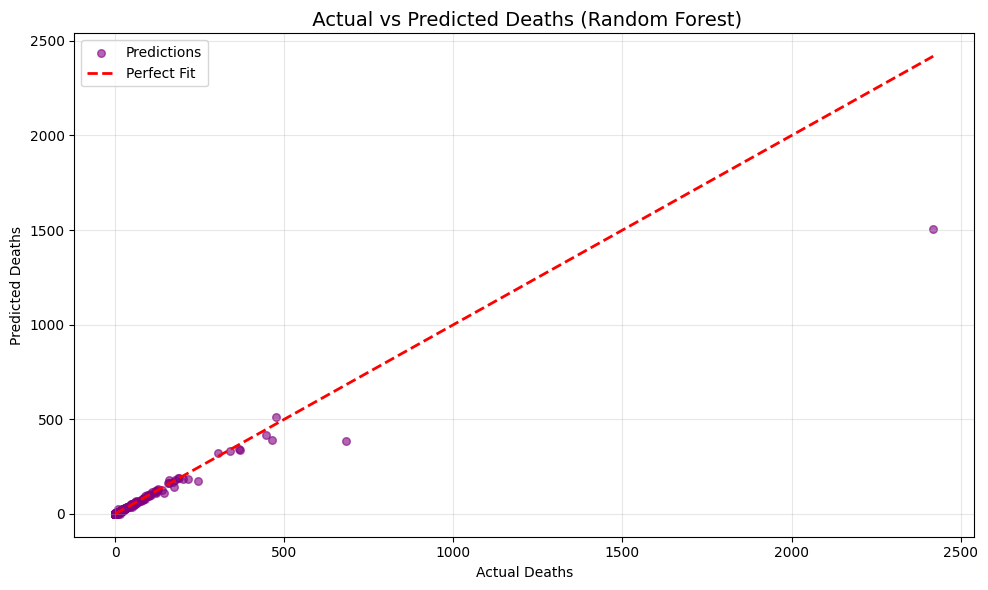

 Plot 6 Done!


In [17]:
# Plot 6: Actual vs Predicted Deaths
plt.figure(figsize=(10, 6))

plt.scatter(y_test2, y_pred_rf, alpha=0.6, color='purple', s=30, label='Predictions')
plt.plot([y_test2.min(), y_test2.max()], [y_test2.min(), y_test2.max()],
         color='red', lw=2, ls='--', label='Perfect Fit')
plt.title(' Actual vs Predicted Deaths (Random Forest)', fontsize=14)
plt.xlabel('Actual Deaths')
plt.ylabel('Predicted Deaths')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(" Plot 6 Done!")

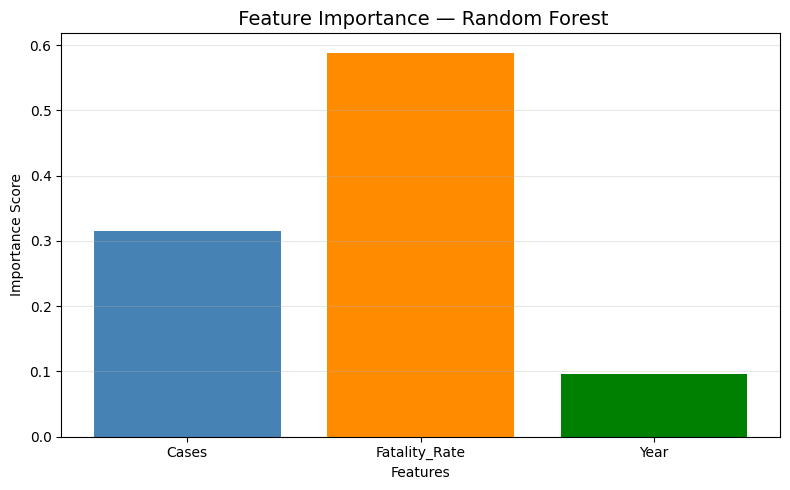

 Plot 7 Done!


In [18]:
# Plot 7: Feature Importance
plt.figure(figsize=(8, 5))

features = ['Cases', 'Fatality_Rate', 'Year']
importance = rf_model.feature_importances_

plt.bar(features, importance, color=['steelblue', 'darkorange', 'green'])
plt.title(' Feature Importance — Random Forest', fontsize=14)
plt.xlabel('Features')
plt.ylabel('Importance Score')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print(" Plot 7 Done!")

In [22]:
print("=" * 55)
print("    GLOBAL CHOLERA ANALYTICS — PROJECT SUMMARY")
print("=" * 55)

print(f"""
 DATASET:
   Total Records  : {len(df)} rows
   Countries      : {df['Country'].nunique()}
   Year Range     : {df['Year'].min()} – {df['Year'].max()}
   WHO Regions    : {df['WHO_Region'].nunique()}

🔍 KEY INSIGHTS:
    Most Affected  : {df.groupby('Country')['Cases'].sum().idxmax()}
    Most Deaths    : {df.groupby('Country')['Deaths'].sum().idxmax()}
    Worst Year     : {df.groupby('Year')['Cases'].sum().idxmax()}
     Highest Risk   : {df.groupby('WHO_Region')['Fatality_Rate'].mean().idxmax()}

 ML MODEL (Random Forest):
   R² Score       : 0.8786
   Features Used  : Cases, Fatality Rate, Year
   
 TOOLS USED:
   Pandas | NumPy | Matplotlib | Seaborn | Scikit-learn
""")
print("=" * 55)
print("         Project Complete! Resume Ready!")
print("=" * 55)

    GLOBAL CHOLERA ANALYTICS — PROJECT SUMMARY

 DATASET:
   Total Records  : 2492 rows
   Countries      : 162
   Year Range     : 1949 – 2016
   WHO Regions    : 6

🔍 KEY INSIGHTS:
    Most Affected  : India
    Most Deaths    : India
    Worst Year     : 1991
     Highest Risk   : South-East Asia

 ML MODEL (Random Forest):
   R² Score       : 0.8786
   Features Used  : Cases, Fatality Rate, Year
   
 TOOLS USED:
   Pandas | NumPy | Matplotlib | Seaborn | Scikit-learn

         Project Complete! Resume Ready!
